# SECTION 1 — Environment Setup

# Abalone Regression Experiment

This notebook evaluates the performance of:

- Single regression
- MixCobra and GradientCobra aggregation

on the Abalone dataset.

Metrics:
- MAE
- MSE
- RMSE
- R2

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
)


# SECTION 2 — Dataset Loading

In [3]:
try:
    from kagglehub import dataset_download
except ImportError:
    %pip install kagglehub
    from kagglehub import dataset_download

path = dataset_download("rodolfomendes/abalone-dataset")
os.listdir(path)


['abalone.csv']

In [4]:
df = pd.read_csv(os.path.join(path, "abalone.csv"))
df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [5]:
df.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


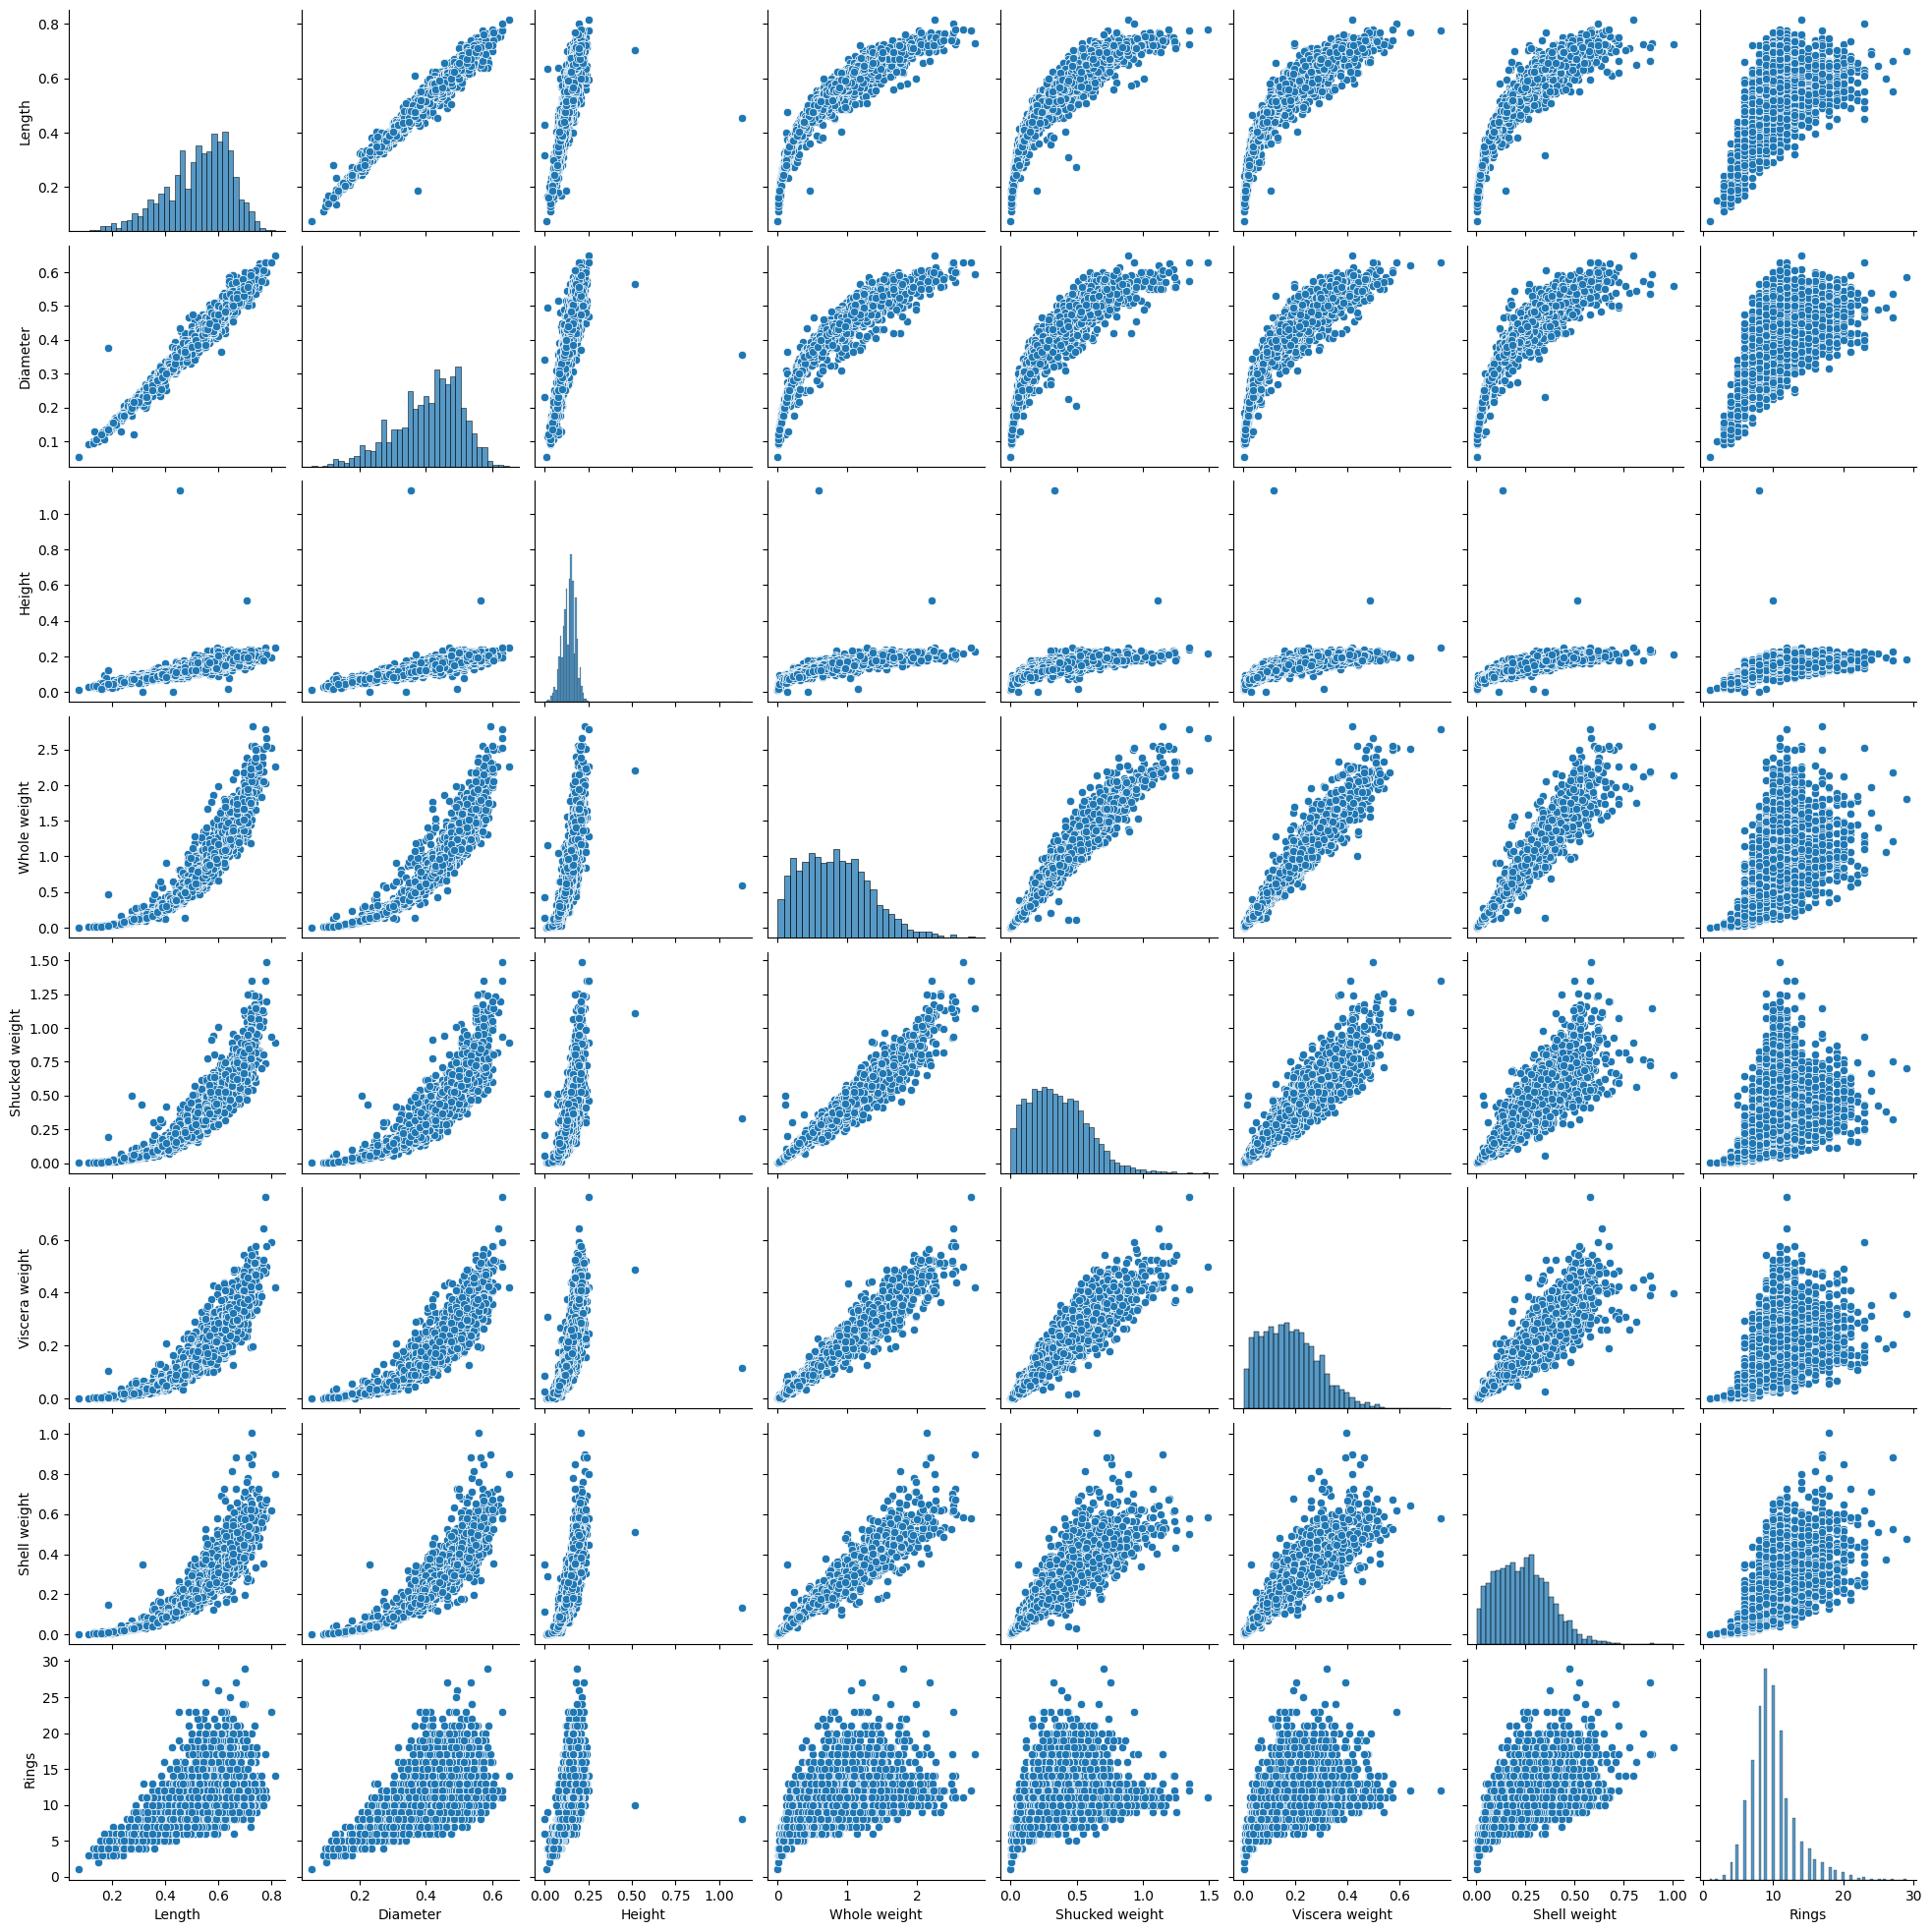

In [6]:
sns.pairplot(df.drop(columns=['Sex']))

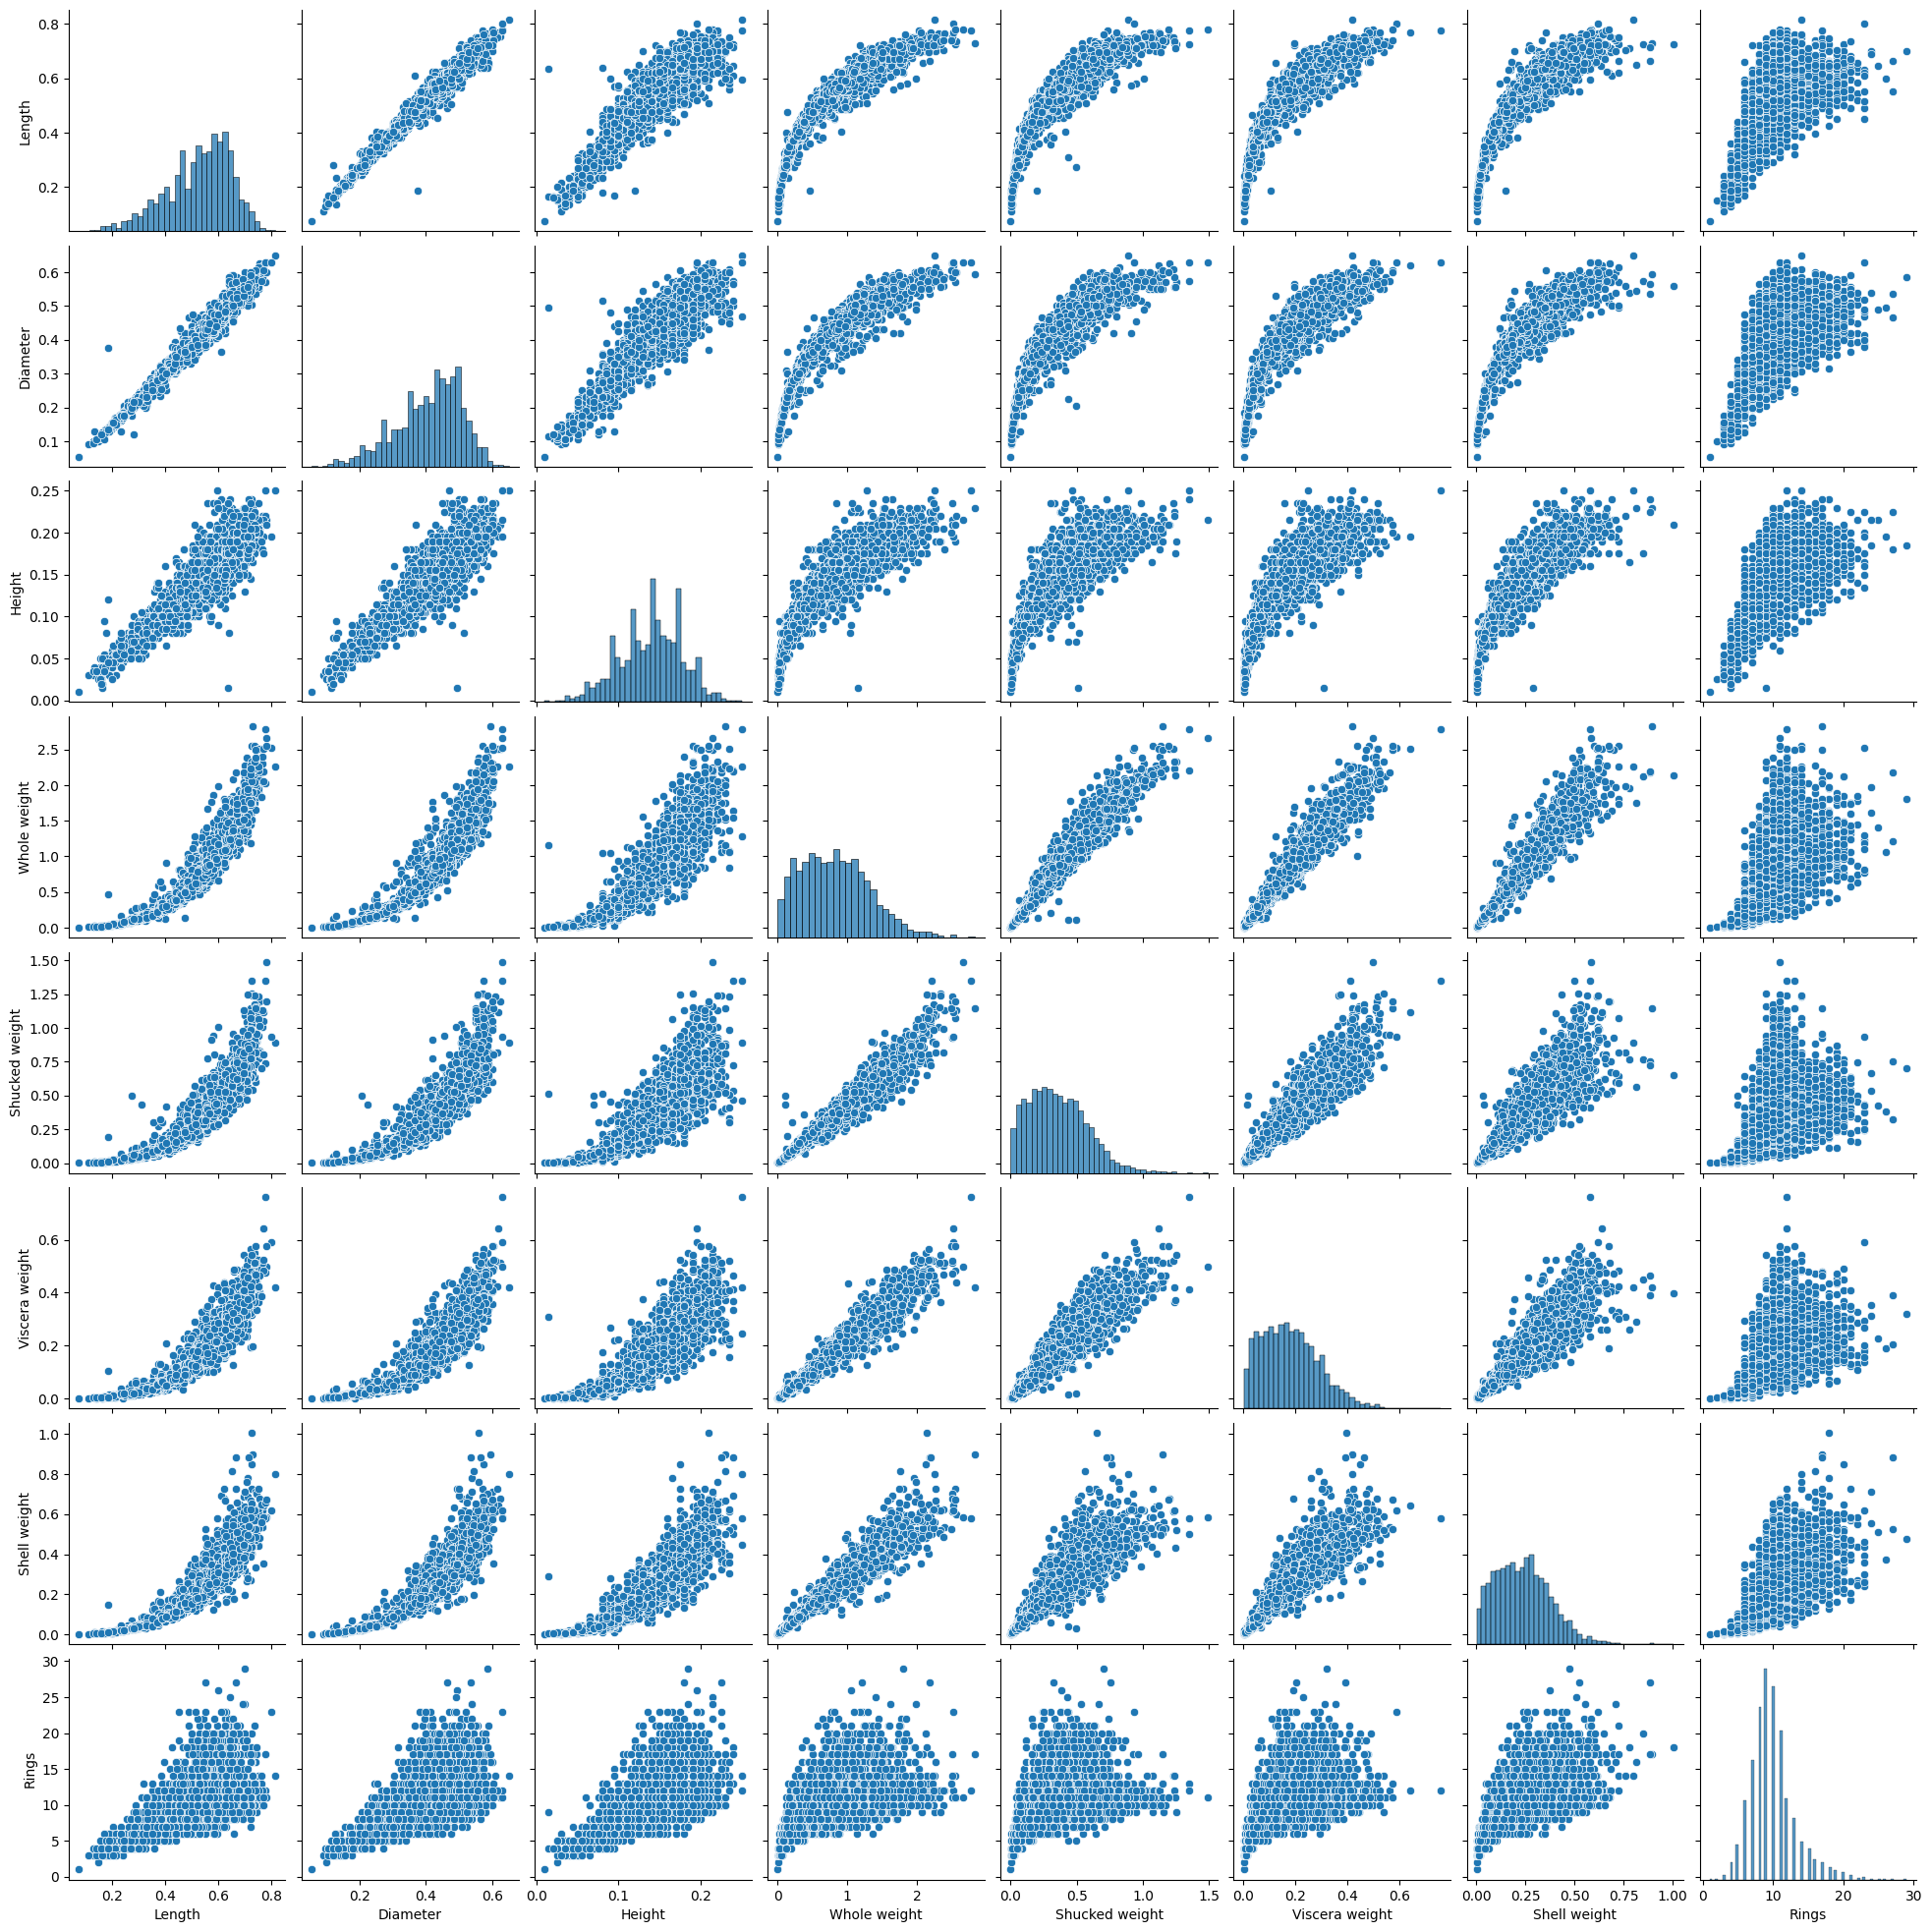

In [7]:
df.query('Height == 0')
df = df.query('Height > 0 and Height < 0.5')
sns.pairplot(df.drop(columns=['Sex']))

# SECTION 3 — Exploratory Data Analysis

In [8]:
print(df.shape)
df.info()

(4173, 9)
<class 'pandas.DataFrame'>
Index: 4173 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4173 non-null   str    
 1   Length          4173 non-null   float64
 2   Diameter        4173 non-null   float64
 3   Height          4173 non-null   float64
 4   Whole weight    4173 non-null   float64
 5   Shucked weight  4173 non-null   float64
 6   Viscera weight  4173 non-null   float64
 7   Shell weight    4173 non-null   float64
 8   Rings           4173 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 326.0 KB


In [9]:
df.isnull().sum()

Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked weight    0
Viscera weight    0
Shell weight      0
Rings             0
dtype: int64

# SECTION 4 — Data Preprocessing

In [10]:
target = "Rings"

X = df.drop(columns=[target])
y = df[target]

In [11]:
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [13]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

# SECTION 5 — Train Models

In [14]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

models = {
    "ridge": Ridge(alpha=1.0),
    "random_forest_regressor" : RandomForestRegressor(n_estimators=300, random_state=42),
    "svr": SVR(),
    "gradient_boosting_regressor" : GradientBoostingRegressor(),
    "k_neighbors_regressor": KNeighborsRegressor()
}

def evaluate_regression(y_true, y_pred):
    metrics = {
        "MAE" : mean_absolute_error(y_true, y_pred),
        "MSE" : mean_squared_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2"  : r2_score(y_true, y_pred)
    }
    return metrics

In [15]:
results = {}
for name, model in models.items():
    clf = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    metrics = evaluate_regression(y_test, y_pred)
    results[name] = metrics

In [16]:
from cobra.gradientcobra import GradientCOBRA

X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)

gradientcobra = GradientCOBRA(
    estimators=models.keys(),
    random_state=42,
)
start_fit = time.perf_counter()
gradientcobra.fit(X_train_p, y_train)
fit_time = time.perf_counter() - start_fit

start_pred = time.perf_counter()
y_pred = gradientcobra.predict(X_test_p)
predict_time = time.perf_counter() - start_pred

metrics = evaluate_regression(y_test, y_pred)
results["gradientcobra"] = metrics
print(f"Results for gradientcobra: {metrics}\n")
print(f"Time computing : fit {fit_time}, predict {predict_time}")

search: 100%|██████████| 300/300 [00:03<00:00, 79.24it/s]


Results for gradientcobra: {'MAE': 1.5236585776544531, 'MSE': 4.864915955750177, 'RMSE': 2.2056554481038457, 'R2': 0.594010664198142}

Time computing : fit 6.820927041000687, predict 1.4174556250072783


In [17]:
gradientcobra.optimization_outputs_

{'method': 'grid',
 'optimizer': 'grid',
 'bandwidth': 6.421762541806021,
 'score': 4.423173205935029,
 'history':      iter     score      risk  bandwidth
 0       0  9.879098  9.879098   0.001000
 1       1  9.691073  9.691073   0.034441
 2       2  9.509593  9.509593   0.067883
 3       3  9.334402  9.334402   0.101324
 4       4  9.165252  9.165252   0.134766
 ..    ...       ...       ...        ...
 295   295  4.473308  4.473308   9.866234
 296   296  4.474150  4.474150   9.899676
 297   297  4.474996  4.474996   9.933117
 298   298  4.475848  4.475848   9.966559
 299   299  4.476704  4.476704  10.000000
 
 [300 rows x 4 columns],
 'evaluations': 300}

In [18]:
results_df = pd.DataFrame(results).T
results_df.sort_values(by="R2", ascending=False)

,MAE,MSE,RMSE,R2
gradientcobra,1.523659,4.864916,2.205655,0.594011
gradient_boosting_regressor,1.534203,4.929053,2.220147,0.588658
ridge,1.583995,4.966736,2.228617,0.585514
svr,1.488849,4.987380,2.233244,0.583791
random_forest_regressor,1.549832,5.001486,2.236400,0.582614
k_neighbors_regressor,1.602635,5.530395,2.351679,0.538475


<Axes: xlabel='bandwidth', ylabel='score'>

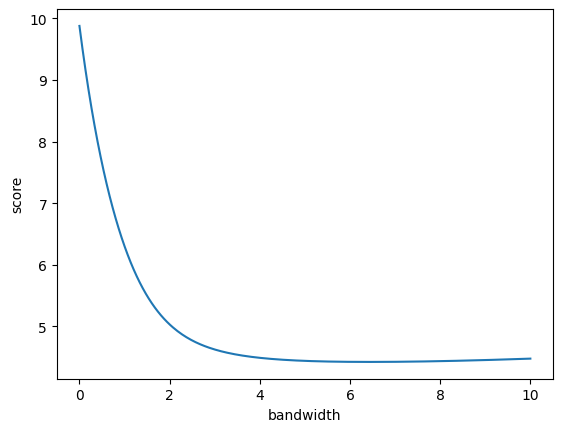

In [19]:
df_output = gradientcobra.optimization_outputs_['history']
sns.lineplot(df_output, x='bandwidth', y='score')

In [20]:
from cobra.mixcobra import MixCOBRARegressor

mixcobra = MixCOBRARegressor(
    opt_method="grad",
    optimizer="gd",
    max_iter=300,
    learning_rate=1,
    random_state=42
)

start_fit = time.perf_counter()
mixcobra.fit(X_train_p, y_train)
fit_time = time.perf_counter() - start_fit

start_pred = time.perf_counter()
y_pred = mixcobra.predict(X_test_p)
predict_time = time.perf_counter() - start_pred

metrics = evaluate_regression(y_test, y_pred)
results["mixcobra"] = metrics
print(f"Results for mixcobra: {metrics}\n")
print(f"Time computing : fit {fit_time}, predict {predict_time}")

iter=300 | score=4.3299 | grad=[-0.00282789 -0.00134158] | lr=0.667650: 100%|██████████| 300/300 [00:20<00:00, 14.79it/s]

Results for mixcobra: {'MAE': 1.5210189180611668, 'MSE': 4.818770497773041, 'RMSE': 2.1951698106918838, 'R2': 0.5978616174324451}

Time computing : fit 20.80535341599898, predict 0.051677166993613355


In [21]:
mixcobra.optimization_outputs_

{'method': 'grad',
 'score': np.float64(4.3299131968395885),
 'history':      iter     score                                              grad  \
 0       1  4.609502      [-0.03237778045672712, -0.33360447737607046]   
 1       2  4.544837      [-0.02383832242713879, -0.24687075050877638]   
 2       3  4.507843      [-0.019560304487242774, -0.1998631438127063]   
 3       4  4.483021       [-0.01696276008544828, -0.1696175910836928]   
 4       5  4.464874     [-0.015208065917704516, -0.14824306671101795]   
 ..    ...       ...                                               ...   
 295   296  4.329940    [-0.002845021995767638, -0.001401141425105834]   
 296   297  4.329933   [-0.002840709889539994, -0.0013860290692946364]   
 297   298  4.329926  [-0.0028364199877728424, -0.0013710677038147878]   
 298   299  4.329920   [-0.002832147849574085, -0.0013562528877741897]   
 299   300  4.329913  [-0.0028278934749437212, -0.0013415846211728422]   
 
      grad_norm       lr     alpha    

In [22]:
results_df = pd.DataFrame(results).T
results_df.sort_values(by="R2", ascending=False)

,MAE,MSE,RMSE,R2
mixcobra,1.521019,4.818770,2.195170,0.597862
gradientcobra,1.523659,4.864916,2.205655,0.594011
gradient_boosting_regressor,1.534203,4.929053,2.220147,0.588658
ridge,1.583995,4.966736,2.228617,0.585514
svr,1.488849,4.987380,2.233244,0.583791
random_forest_regressor,1.549832,5.001486,2.236400,0.582614
k_neighbors_regressor,1.602635,5.530395,2.351679,0.538475


# SECTION 6 — External training

In [23]:
X_base, X_agg, y_base, y_agg = train_test_split(
    X_train_p,
    y_train,
    test_size=0.5,
    random_state=42,
)

fit_models = {}
for name, model in models.items():
    model.fit(X_base, y_base)
    fit_models[name] = model

P_agg = np.column_stack([
    m.predict(X_agg)
    for m in fit_models.values()
])

P_test = np.column_stack([
    m.predict(X_test_p)
    for m in fit_models.values()
])

gradientcobra = GradientCOBRA(
    estimators=fit_models.keys(),
    random_state=42,
)

gradientcobra.fit(
    X=P_agg,
    y=y_agg,
    as_predictions=True
)

y_pred = gradientcobra.predict(
    X=P_test
)

metrics = evaluate_regression(y_test, y_pred)
metrics


search: 100%|██████████| 300/300 [00:03<00:00, 79.32it/s]


{'MAE': 1.5280251118794521,
 'MSE': 4.9304972701495995,
 'RMSE': 2.2204723078997404,
 'R2': 0.588537740407431}

MAE -> MAPE
delete MSE only use RMSE / average (y_test)
R ^ 2